# N-BEATS: model experiment

One **global** model over all ~3,300 Store x Dept series


In [ ]:

import importlib.util, os, subprocess, sys
from pathlib import Path

IN_COLAB = importlib.util.find_spec("google.colab") is not None
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    ROOT = Path("/content/drive/MyDrive/ML_FINAL_PROJECT")
else:
    ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
                if (p / "data" / "train.csv.zip").exists())


PACKAGES = {"darts": "u8darts[torch]", "optuna": "optuna", "mlflow": "mlflow"}
installed = [pkg for mod, pkg in PACKAGES.items()
             if importlib.util.find_spec(mod) is None]
for pkg in installed:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

if installed and IN_COLAB:

    print("Installed:", installed, flush=True)
    print("Restarting the Colab runtime now. Run all cells again.", flush=True)
    os.kill(os.getpid(), 9)

sys.path.insert(0, str(ROOT))
print("ROOT =", ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ROOT = /content/drive/MyDrive/ML_FINAL_PROJECT


In [ ]:
import json
import tempfile

import numpy as np
import pandas as pd
import mlflow
import torch

from src.ts_pipeline import GlobalDartsPipeline, DartsPipelinePyfunc

torch.set_float32_matmul_precision("medium")

from src.preprocessing import Cleaner
from src.validation import FOLDS, evaluate, wmae
from src.experiment_utils import setup_mlflow, run_stage, log_table
from src import ts_data

train    = pd.read_csv(ROOT / "data/train.csv.zip")
test     = pd.read_csv(ROOT / "data/test.csv.zip")
features = pd.read_csv(ROOT / "data/features.csv.zip")
stores   = pd.read_csv(ROOT / "data/stores.csv")

DAGSHUB_REPO = "ZukaCS/ML_FINAL_PROJECT"
print("tracking:", setup_mlflow(ROOT, dagshub_repo=DAGSHUB_REPO))
print("train", train.shape, "| test", test.shape)

/usr/local/lib/python3.12/dist-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(
/usr/local/lib/python3.12/dist-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


DagsHub username (leave blank to log locally): ZukaCS
DagsHub token: ··········
tracking: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow
train (421570, 5) | test (115064, 4)


In [ ]:
_clean = Cleaner(stores, features).fit_transform(train)
_series, _, _report = ts_data.build_target_series(_clean)


_rows = _clean.sample(500, random_state=0)
for _, _r in _rows.iterrows():
    _ts = _series[(_r["Store"], _r["Dept"])]
    _pos = _ts.time_index.get_loc(pd.Timestamp(_r["Date"]))
    assert np.isclose(_ts.values(copy=False).ravel()[_pos], _r["Weekly_Sales"],
                      rtol=1e-4, atol=1.0)


assert all(_s.end_time() == _clean["Date"].max() for _s in _series.values())

print("sanity checks passed |", _report)

sanity checks passed | {'n_series': 3331, 'n_weeks_common_grid': 143, 'n_gap_weeks_filled': 27667, 'n_tail_padded_series': 372, 'n_tail_padded_weeks': 12816, 'n_late_start_series': 376}


In [ ]:
from darts.models import NBEATSModel

PL_KWARGS = {"accelerator": "auto", "enable_progress_bar": False,
             "enable_model_summary": False, "logger": False}

NBEATS_DEFAULT = dict(
    input_chunk_length=52, output_chunk_length=13,
    generic_architecture=True, num_stacks=4, num_blocks=1, num_layers=4,
    layer_widths=256, expansion_coefficient_dim=5, trend_polynomial_degree=2,
    dropout=0.0,
    n_epochs=25, batch_size=512, optimizer_kwargs={"lr": 1e-3},
    loss_fn=torch.nn.L1Loss(),   # L1 = MAE; with the 5x holiday sample
                                 # weight below the training loss is WMAE
    random_state=42, pl_trainer_kwargs=PL_KWARGS)

PIPE_DEFAULT = dict(covariate_preset="none", log_target=True,
                    scale=True, use_statics=False, max_samples_per_ts=10,
                    holiday_weight=5.0)   # 5x holiday weight: loss = WMAE

def make_pipeline(model_params=None, pipe_params=None):
    mp = {**NBEATS_DEFAULT, **(model_params or {})}
    pp = {**PIPE_DEFAULT, **(pipe_params or {})}
    return GlobalDartsPipeline(
        stores, features,
        model_factory=lambda: NBEATSModel(**mp),
        input_chunk_length=mp["input_chunk_length"],
        output_chunk_length=mp["output_chunk_length"], **pp)

def full_config(model_params=None, pipe_params=None):
    return {**NBEATS_DEFAULT, **(model_params or {}),
            **PIPE_DEFAULT, **(pipe_params or {})}

## 2. Stage: `NBEATS_Preprocessing`



In [ ]:
mlflow.set_experiment("NBEATS_Training")
_clean_full = Cleaner(stores, features).fit_transform(train)
_, _, prep_report = ts_data.build_target_series(_clean_full)

with mlflow.start_run(run_name="NBEATS_Preprocessing"):
    mlflow.set_tag("stage", "Preprocessing")
    mlflow.log_params({
        "clip_negatives": True,
        "markdown_impute": "zero",
        "cpi_unemp_impute": "ffill_per_store",
        "series_unit": "Store_x_Dept_weekly",
        "reindex_freq": "W-FRI",
        "gap_fill_value": 0,
        "tail_pad_to_common_end_value": 0,
        "late_start_series": "kept_without_backfill",
        "target_transform": "log1p",
        "per_series_scaling": "minmax_fit_in_pipeline_fit",
        "loss_alignment": "L1_loss_with_5x_holiday_sample_weight_equals_WMAE",
        "covariate_scaling": "minmax_over_known_full_range",
        "fallback_predictor": "seasonal_naive_dept_median",
    })
    mlflow.log_metrics({k: float(v) for k, v in prep_report.items()})
prep_report

🏃 View run NBEATS_Preprocessing at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/4/runs/c55fdb9662aa4ec7b89389b45f630aa8
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/4


{'n_series': 3331,
 'n_weeks_common_grid': 143,
 'n_gap_weeks_filled': 27667,
 'n_tail_padded_series': 372,
 'n_tail_padded_weeks': 12816,
 'n_late_start_series': 376}

## 3. Stage: `NBEATS_Feature_Engineering`

N-BEATS consumes only the target series, so feature engineering is the
reshaping itself: no columns added, none renamed.

In [ ]:
mlflow.set_experiment("NBEATS_Training")
with mlflow.start_run(run_name="NBEATS_Feature_Engineering"):
    mlflow.set_tag("stage", "Feature_Engineering")
    mlflow.log_params({
        "future_covariates_built": "none (architecture takes no covariates)",
        "columns_added": "none",
        "columns_renamed": "none",
        "static_covariates_built": "none (not supported by N-BEATS)",
        "input_columns": json.dumps(["Store", "Dept", "Date", "Weekly_Sales"]),
    })
print("feature engineering logged")

🏃 View run NBEATS_Feature_Engineering at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/4/runs/fb4cc8eb0bc241a0a0e1bd122befe30e
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/4
feature engineering logged


## 4. Stage: `NBEATS_Feature_Selection`

From the original data only `Store`, `Dept`, `Date`, `Weekly_Sales` are used
. All exogenous columns are excluded
because the Darts N-BEATS takes no future covariates

In [ ]:
mlflow.set_experiment("NBEATS_Training")
with mlflow.start_run(run_name="NBEATS_Feature_Selection"):
    mlflow.set_tag("stage", "Feature_Selection")
    mlflow.log_params({
        "target_columns_used": json.dumps(["Store", "Dept", "Date", "Weekly_Sales"]),
        "selected_future_covariates": "none",
        "selected_static_covariates": "none",
        "decided_by": "fixed (architecture capability)",
        "rationale": ("Darts N-BEATS supports no future/static covariates; "
                      "seasonality must come from the input window, so "
                      "input_chunk_length >= 52 is part of the CV space"),
    })
print("feature selection logged")

🏃 View run NBEATS_Feature_Selection at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/4/runs/56590ebe5b624cf59458de10c1407ee0
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/4
feature selection logged


## 5. Stage: `NBEATS_CV`: hyperparameter tuning

Optuna TPE, 25 trials x 3 folds, every child logs the complete config.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=25` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/pytorch_light

🏃 View run trial_000 at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/4/runs/fc12a4676f8f44dcb2f561fa25b63e5b
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/4
trial 000: wmae_mean=3,014


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=25` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/pytorch_light

🏃 View run trial_001 at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/4/runs/7deb5f7b95a24ec98b6c57e71110665d
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/4
trial 001: wmae_mean=3,314


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=25` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/pytorch_light

...

🏃 View run trial_023 at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/4/runs/38477975ffba41648886d69d076a1a60
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/4
trial 023: wmae_mean=2,225


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=25` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/pytorch_light

🏃 View run trial_024 at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/4/runs/1752999e980d493d97baa78de6a8f49c
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/4
trial 024: wmae_mean=2,611


/tmp/ipykernel_2835/2943550102.py:65: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  mlflow.log_figure(plot_optimization_history(study).figure,
/tmp/ipykernel_2835/2943550102.py:67: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  mlflow.log_figure(plot_param_importances(study).figure,


🏃 View run NBEATS_CV at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/4/runs/4322990fc7004914999160a63f55c963
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/4
best wmae_mean: 2220.9
best params: {'chunk_choice': 8, 'generic_architecture': True, 'num_stacks': 8, 'num_blocks_generic': 1, 'expansion_coefficient_dim': 3, 'num_layers': 2, 'layer_widths': 512, 'dropout': 0.1, 'batch_size': 512, 'lr': 0.0007680247295665285}


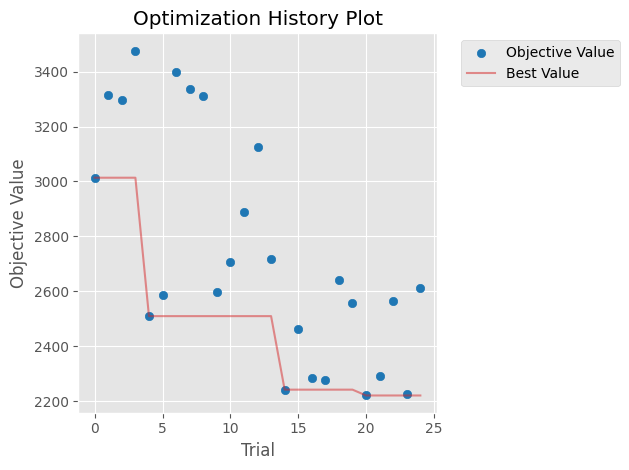

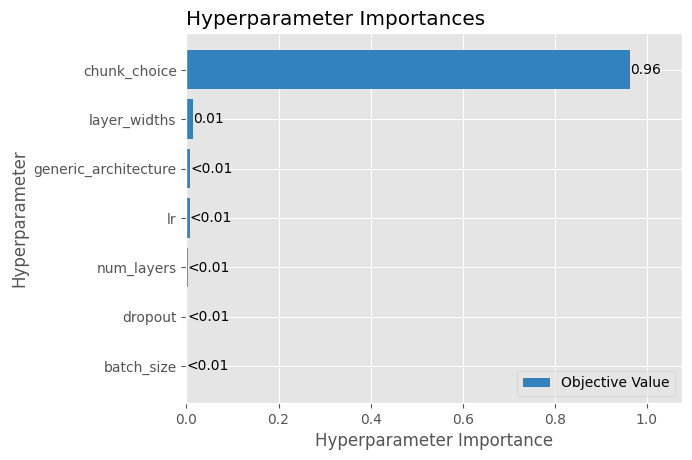

In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS = 25
CHUNKS = [(26, 13), (26, 26), (26, 39), (39, 13), (39, 26), (39, 39),
          (52, 13), (52, 26), (65, 13)]

def sample_params(trial):
    ci, co = CHUNKS[trial.suggest_int("chunk_choice", 0, len(CHUNKS) - 1)]
    generic = trial.suggest_categorical("generic_architecture", [True, False])
    if generic:
        arch = dict(
            generic_architecture=True,
            num_stacks=trial.suggest_categorical("num_stacks", [2, 4, 8]),
            num_blocks=trial.suggest_categorical("num_blocks_generic", [1, 2]),
            expansion_coefficient_dim=trial.suggest_categorical(
                "expansion_coefficient_dim", [3, 5]))
    else:
        arch = dict(
            generic_architecture=False,
            num_blocks=trial.suggest_categorical("num_blocks_interp", [2, 3]),
            trend_polynomial_degree=trial.suggest_categorical(
                "trend_polynomial_degree", [2, 3]))
    model_params = dict(
        input_chunk_length=ci, output_chunk_length=co, **arch,
        num_layers=trial.suggest_categorical("num_layers", [2, 4]),
        layer_widths=trial.suggest_categorical("layer_widths", [128, 256, 512]),
        dropout=trial.suggest_categorical("dropout", [0.0, 0.1]),
        batch_size=trial.suggest_categorical("batch_size", [512, 1024]),
        optimizer_kwargs={"lr": trial.suggest_float("lr", 1e-4, 1e-2, log=True)})
    return model_params, {}

mlflow.set_experiment("NBEATS_Training")
with mlflow.start_run(run_name="NBEATS_CV"):
    mlflow.set_tag("stage", "CV")
    mlflow.log_params({"n_trials": N_TRIALS, "search": "optuna_tpe_seed42",
                       "cv_scope": "all_series_3_rolling_folds"})

    def objective(trial):
        model_params, pipe_params = sample_params(trial)
        cfg = full_config(model_params, pipe_params)
        with mlflow.start_run(run_name=f"trial_{trial.number:03d}", nested=True):
            mlflow.log_params({k: str(v) for k, v in cfg.items()})
            metrics = evaluate(lambda: make_pipeline(model_params, pipe_params),
                               train)
            mlflow.log_metrics(metrics)
        print(f"trial {trial.number:03d}: wmae_mean={metrics['wmae_mean']:,.0f}")
        import gc
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        return metrics["wmae_mean"]

    study = optuna.create_study(direction="minimize",
                                sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=N_TRIALS)

    BEST_MODEL_PARAMS, BEST_PIPE_PARAMS = sample_params(
        optuna.trial.FixedTrial(study.best_params))
    mlflow.log_metric("best_wmae_mean", study.best_value)
    mlflow.log_params({f"best_{k}": str(v) for k, v in study.best_params.items()})
    try:
        from optuna.visualization.matplotlib import (
            plot_optimization_history, plot_param_importances)
        mlflow.log_figure(plot_optimization_history(study).figure,
                          "cv_optimization_history.png")
        mlflow.log_figure(plot_param_importances(study).figure,
                          "cv_param_importances.png")
    except Exception as e:
        print("optuna plots skipped:", e)

print("best wmae_mean:", round(study.best_value, 1))
print("best params:", study.best_params)

## 6. Stage: `NBEATS_Final`

Re-score the winning config with the shared 3-fold CV, retrain it on **all**
training data, and log the whole pipeline as an MLflow pyfunc model. and create submission file

In [ ]:
mlflow.set_experiment("NBEATS_Training")
with mlflow.start_run(run_name="NBEATS_Final") as final_run:
    mlflow.set_tag("stage", "Final")

    final_cfg = full_config(BEST_MODEL_PARAMS, BEST_PIPE_PARAMS)
    final_pipe = make_pipeline(BEST_MODEL_PARAMS, BEST_PIPE_PARAMS).fit(train)
    final_metrics = evaluate(lambda: make_pipeline(BEST_MODEL_PARAMS, BEST_PIPE_PARAMS), train)
    mlflow.log_params({k: str(v) for k, v in final_cfg.items()})
    mlflow.log_params({("pipe_" + k): str(v)
                       for k, v in final_pipe.get_params().items()})
    mlflow.log_metrics(final_metrics)


    preds = final_pipe.predict(test)
    assert len(preds) == len(test) and not np.isnan(preds).any()
    mlflow.log_metrics({"n_fallback_rows_test": final_pipe.last_fallback_rows_,
                       })

    with tempfile.TemporaryDirectory() as _td:
        _pipe_dir = Path(_td) / "pipeline"
        final_pipe.save(_pipe_dir)
        mlflow.pyfunc.log_model(
            name="model", python_model=DartsPipelinePyfunc(),
            artifacts={"pipeline_dir": str(_pipe_dir)},
            code_paths=[str(ROOT / "src")],
            input_example=test.head(5))

    sub = pd.DataFrame({
        "Id": test["Store"].astype(str) + "_" + test["Dept"].astype(str)
              + "_" + test["Date"].astype(str),
        "Weekly_Sales": preds,
    })
    (ROOT / "submissions").mkdir(exist_ok=True)
    sub_path = ROOT / "submissions" / "submission_nbeats.csv"
    sub.to_csv(sub_path, index=False)
    mlflow.log_artifact(str(sub_path))

print("final CV:", {k: round(v, 1) for k, v in final_metrics.items()})
print("run_id:", final_run.info.run_id)
sub.head()

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=25` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/pytorch_light

2026/07/11 20:08:56 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


🏃 View run NBEATS_Final at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/4/runs/667ebf02805d4ef284386a76a30354dc
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/4
final CV: {'wmae_fold1': 3203.8, 'wmae_fold2': 1955.3, 'wmae_fold3': 1503.6, 'wmae_mean': 2220.9}
run_id: 667ebf02805d4ef284386a76a30354dc


,Id,Weekly_Sales
0,1_1_2012-11-02,24449.560732
1,1_1_2012-11-09,23498.349655
2,1_1_2012-11-16,22977.641746
3,1_1_2012-11-23,26788.606732
4,1_1_2012-11-30,27011.317708
